# Part A

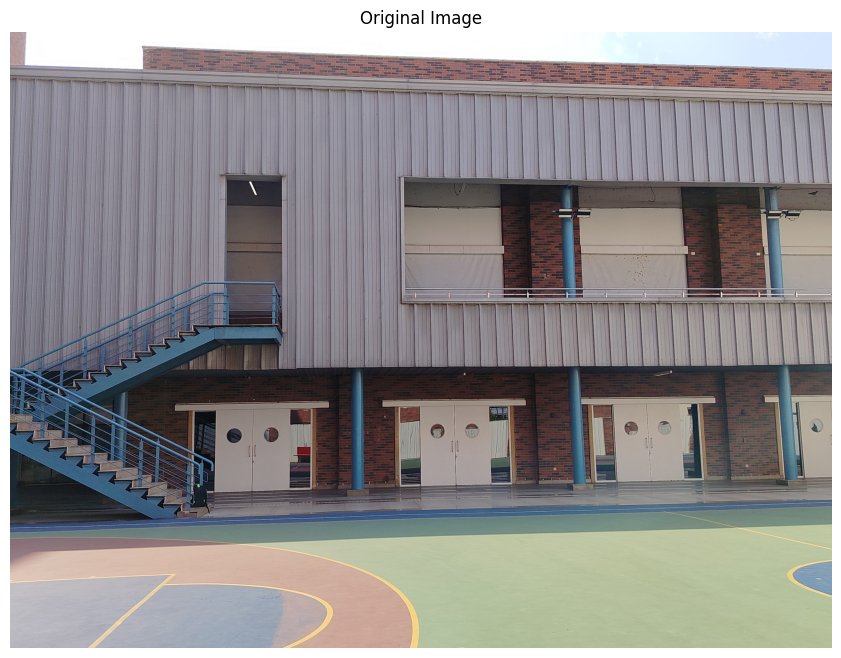

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

img = cv2.imread('corner_det.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
plt.title("Original Image")
plt.axis('off')
plt.show()


In [10]:
img.shape

(3000, 4000, 3)

In [ ]:

scale_factor = desired_width / img.shape[1]
desired_height = int(img.shape[0] * scale_factor)

display_img = cv2.resize(img, (desired_width, desired_height))
temp_img = display_img.copy()
ground_truth = []

def click_event(event, x, y, flags, params):
    if event == cv2.EVENT_LBUTTONDOWN:

        orig_x = int(x / scale_factor)
        orig_y = int(y / scale_factor)
        ground_truth.append([orig_x, orig_y])
        
        cv2.circle(temp_img, (x, y), 4, (0, 255, 0), -1)
        cv2.imshow('Click 50 Corners', temp_img)
        
        if len(ground_truth) % 10 == 0:
            print(f"Captured {len(ground_truth)} points...")

cv2.imshow('Click 50 Corners', temp_img)
cv2.setMouseCallback('Click 50 Corners', click_event)
cv2.waitKey(0)
cv2.destroyAllWindows()

gt_points = np.array(ground_truth)
print(f"Total Ground Truth Points captured: {len(gt_points)}")

Captured 10 points...
Captured 20 points...
Captured 30 points...
Captured 40 points...
Captured 50 points...
Total Ground Truth Points captured: 50


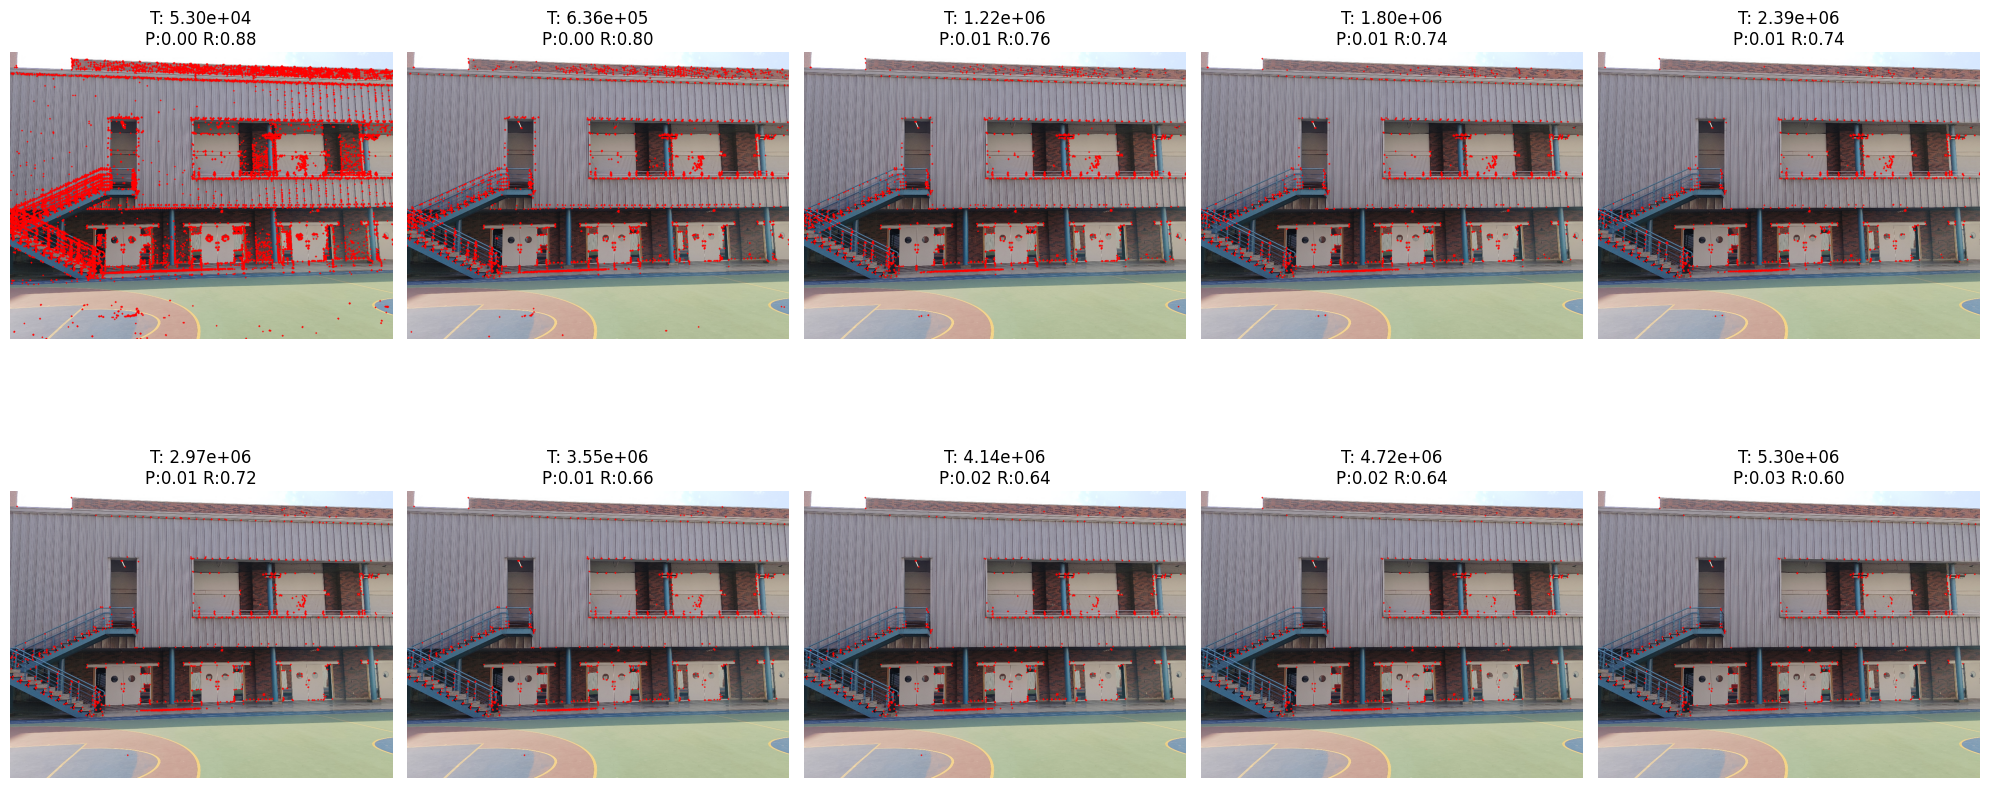

In [ ]:
import pandas as pd

dst = cv2.cornerHarris(gray, 2, 3, 0.04)


def get_metrics(harris_map, gt_points, threshold_val, radius=10):
    
    y_coords, x_coords = np.where(harris_map > threshold_val)
    detected_points = np.column_stack((x_coords, y_coords))
    
    if len(detected_points) == 0:
        return 0, 0, detected_points


    tp = 0
    used_gt = set()
    
    for det in detected_points:
    
        dists = np.linalg.norm(gt_points - det, axis=1)
        nearest_gt_idx = np.argmin(dists)
        

        if dists[nearest_gt_idx] < radius and nearest_gt_idx not in used_gt:
            tp += 1
            used_gt.add(nearest_gt_idx)
            
    precision = tp / len(detected_points)
    recall = tp / len(gt_points)
    
    return precision, recall, detected_points

threshold_list = np.linspace(0.001, 0.1, 10) * dst.max()
results = []

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, t in enumerate(threshold_list):
    p, r, pts = get_metrics(dst, gt_points, t)
    results.append({'Threshold': t, 'Precision': p, 'Recall': r})
    
    vis_img = cv2.resize(img, (desired_width, desired_height)) 

    for pt in pts:
        cv2.circle(vis_img, (int(pt[0]*scale_factor), int(pt[1]*scale_factor)), 2, (0, 0, 255), -1)
        
    axes[i].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"T: {t:.2e}\nP:{p:.2f} R:{r:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

df = pd.DataFrame(results)

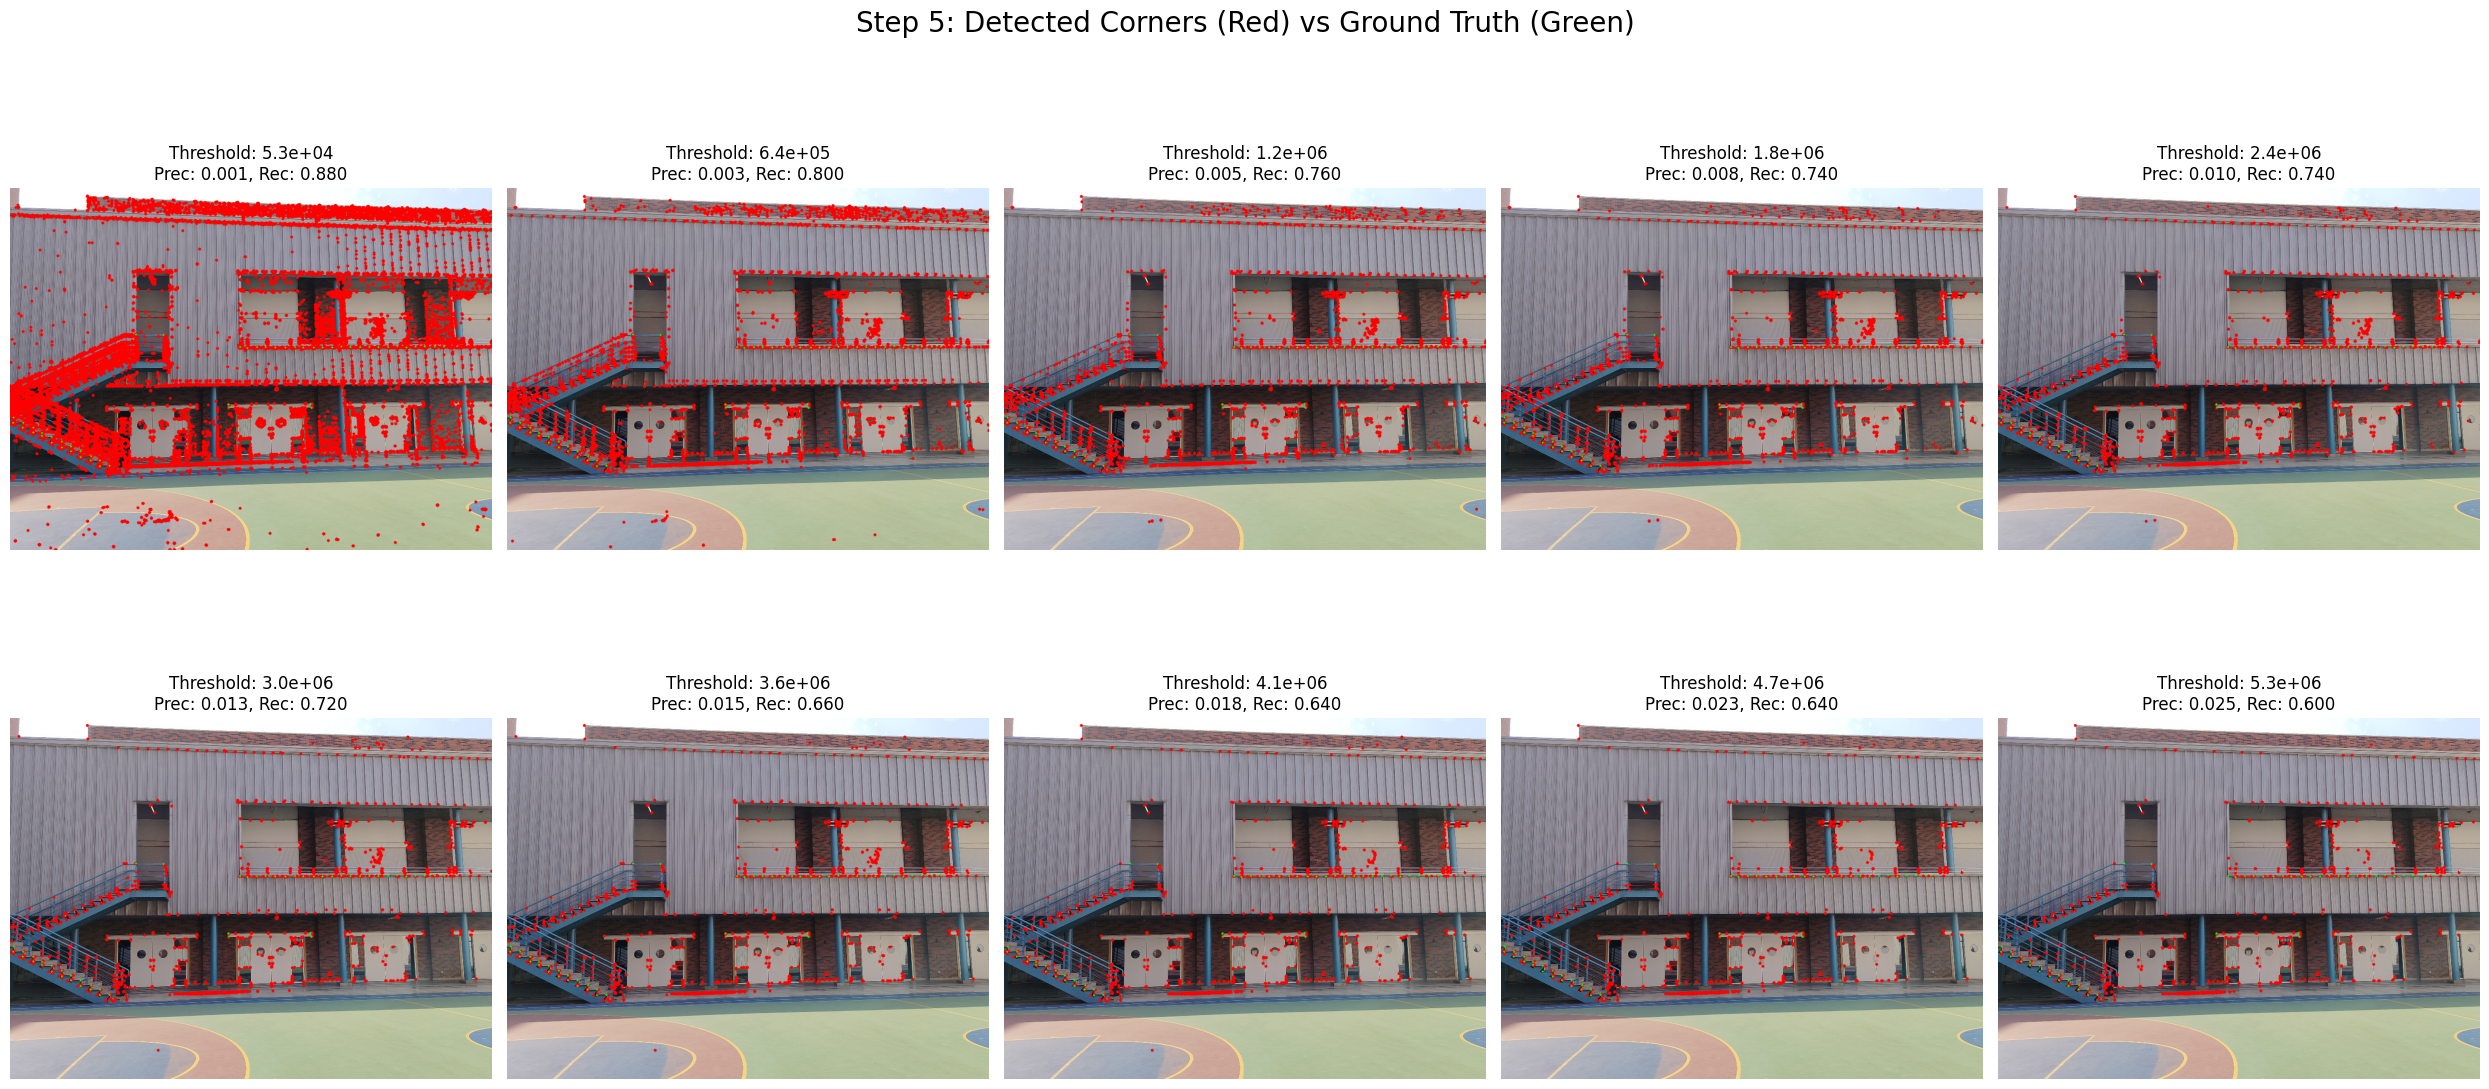

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(25, 12))
axes = axes.flatten()

for i, t in enumerate(threshold_list):

    p, r, detected_pts = get_metrics(dst, gt_points, t)
    
    vis_img = cv2.resize(img, (desired_width, desired_height))
    

    for pt in detected_pts:
        
        cv_x = int(pt[0] * scale_factor)
        cv_y = int(pt[1] * scale_factor)
        cv2.circle(vis_img, (cv_x, cv_y), 3, (0, 0, 255), -1)
    
    for gt in gt_points:
        gt_x = int(gt[0] * scale_factor)
        gt_y = int(gt[1] * scale_factor)
        cv2.circle(vis_img, (gt_x, gt_y), 2, (0, 255, 0), -1)

    axes[i].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Threshold: {t:.1e}\nPrec: {p:.3f}, Rec: {r:.3f}", fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Step 5: Detected Corners (Red) vs Ground Truth (Green)", fontsize=20, y=1.02)
plt.show()

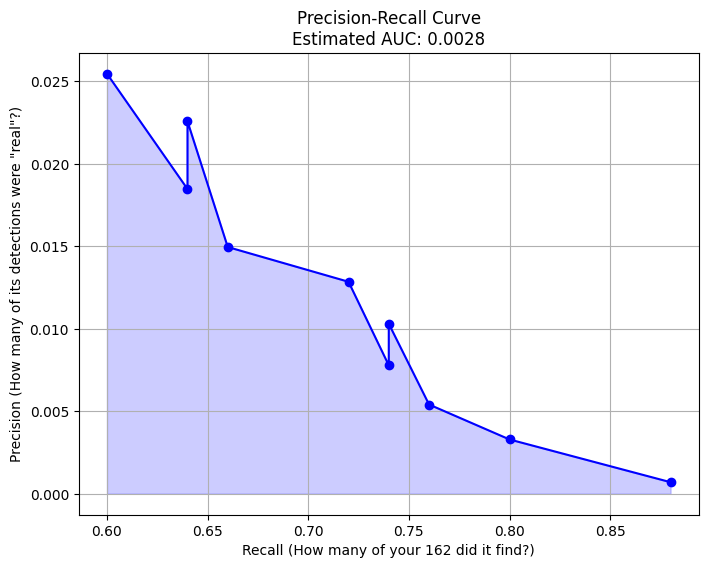

BONUS: The estimated Area Under the Curve is 0.0028


In [ ]:
from sklearn.metrics import auc

df = df.sort_values('Recall')

area = auc(df['Recall'], df['Precision'])

plt.figure(figsize=(8, 6))
plt.plot(df['Recall'], df['Precision'], marker='o', linestyle='-', color='b')
plt.fill_between(df['Recall'], df['Precision'], alpha=0.2, color='b')
plt.title(f'Precision-Recall Curve\nEstimated AUC: {area:.4f}')
plt.xlabel('Recall (How many of your 162 did it find?)')
plt.ylabel('Precision (How many of its detections were "real"?)')
plt.grid(True)
plt.show()

print(f"BONUS: The estimated Area Under the Curve is {area:.4f}")

# Part B

Starting SIFT extraction for 19 images...

oyla_0001.jpg: Found 17478 keypoints
oyla_0003.jpg: Found 17543 keypoints
oyla_0005.jpg: Found 19503 keypoints
oyla_0007.jpg: Found 20916 keypoints
oyla_0009.jpg: Found 22397 keypoints
oyla_0011.jpg: Found 20954 keypoints
oyla_0013.jpg: Found 19417 keypoints
oyla_0015.jpg: Found 19299 keypoints
oyla_0017.jpg: Found 21446 keypoints
oyla_0019.jpg: Found 18428 keypoints
oyla_0021.jpg: Found 19202 keypoints
oyla_0023.jpg: Found 14933 keypoints
oyla_0025.jpg: Found 12302 keypoints
oyla_0027.jpg: Found 10784 keypoints
oyla_0029.jpg: Found 9439 keypoints
oyla_0031.jpg: Found 11939 keypoints
oyla_0033.jpg: Found 12526 keypoints
oyla_0035.jpg: Found 12734 keypoints
oyla_0037.jpg: Found 12056 keypoints


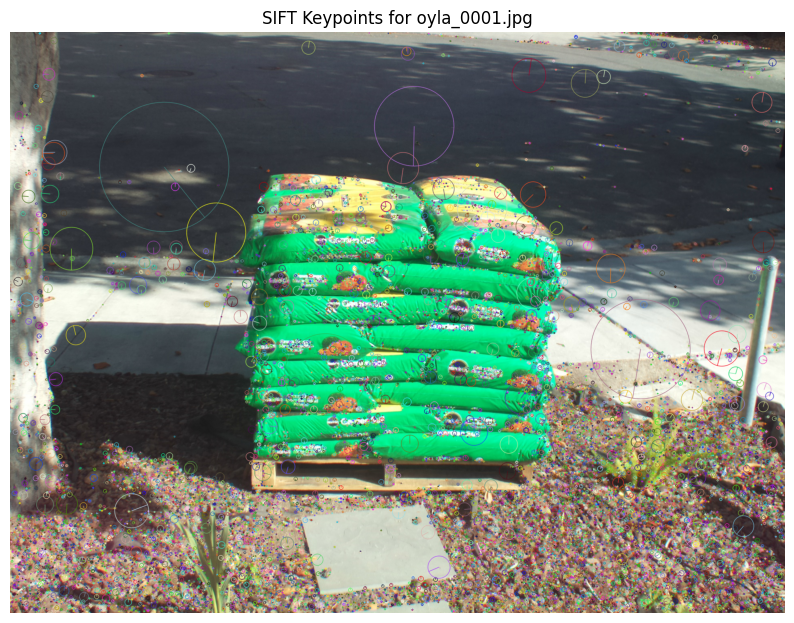

In [ ]:
import os
sift = cv2.SIFT_create()


folder_path = 'rgb_jpg_native/rgb_jpg_native'
image_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])

all_features = {}

print(f"Starting SIFT extraction for {len(image_files)} images...\n")

for filename in image_files:
    img_path = os.path.join(folder_path, filename)
    img = cv2.imread(img_path)
    
    if img is None:
        print(f"Error loading {filename}")
        continue
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    kp, des = sift.detectAndCompute(gray, None)
    
    all_features[filename] = (kp, des)
    
    print(f"{filename}: Found {len(kp)} keypoints")

first_img_name = image_files[0]
first_img = cv2.imread(os.path.join(folder_path, first_img_name))
kp_vis, _ = all_features[first_img_name]

img_with_kp = cv2.drawKeypoints(first_img, kp_vis, None, 
                                flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints for {first_img_name}")
plt.axis('off')
plt.show()

In [ ]:

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

consecutive_pairs = [
    ('oyla_0001.jpg', 'oyla_0003.jpg'),
    ('oyla_0003.jpg', 'oyla_0005.jpg'),
    ('oyla_0005.jpg', 'oyla_0007.jpg'),
    ('oyla_0007.jpg', 'oyla_0009.jpg'),
    ('oyla_0009.jpg', 'oyla_0011.jpg'),
    ('oyla_0011.jpg', 'oyla_0013.jpg'),
    ('oyla_0013.jpg', 'oyla_0015.jpg'),
    ('oyla_0015.jpg', 'oyla_0017.jpg'),
    ('oyla_0017.jpg', 'oyla_0019.jpg'),
    ('oyla_0019.jpg', 'oyla_0021.jpg'),
    ('oyla_0021.jpg', 'oyla_0023.jpg'),
    ('oyla_0023.jpg', 'oyla_0025.jpg'),
    ('oyla_0025.jpg', 'oyla_0027.jpg'),
    ('oyla_0027.jpg', 'oyla_0029.jpg'),
    ('oyla_0029.jpg', 'oyla_0031.jpg'),
    ('oyla_0031.jpg', 'oyla_0033.jpg'),
    ('oyla_0033.jpg', 'oyla_0035.jpg'),
    ('oyla_0035.jpg', 'oyla_0037.jpg'),
    ('oyla_0037.jpg', 'oyla_0001.jpg') 
]

consecutive_costs = []

print("Matching Consecutive Pairs...")
for img1_name, img2_name in consecutive_pairs:
    des1 = all_features[img1_name][1]
    des2 = all_features[img2_name][1]
    
    matches = bf.match(des1, des2)
    
    total_cost = sum(m.distance for m in matches)
    consecutive_costs.append(total_cost)
    
    print(f"Match {img1_name} <-> {img2_name}: Cost = {total_cost:.2f} ({len(matches)} matches)")

avg_consecutive_cost = np.mean(consecutive_costs)
print(f"\nAverage Consecutive Matching Cost: {avg_consecutive_cost:.2f}")

Matching Consecutive Pairs...
Match oyla_0001.jpg <-> oyla_0003.jpg: Cost = 1702388.21 (9421 matches)
Match oyla_0003.jpg <-> oyla_0005.jpg: Cost = 1706512.53 (9823 matches)
Match oyla_0005.jpg <-> oyla_0007.jpg: Cost = 1999100.05 (10450 matches)
Match oyla_0007.jpg <-> oyla_0009.jpg: Cost = 2118923.83 (10254 matches)
Match oyla_0009.jpg <-> oyla_0011.jpg: Cost = 2097786.10 (12075 matches)
Match oyla_0011.jpg <-> oyla_0013.jpg: Cost = 1982562.57 (9989 matches)
Match oyla_0013.jpg <-> oyla_0015.jpg: Cost = 1268463.97 (13352 matches)
Match oyla_0015.jpg <-> oyla_0017.jpg: Cost = 1941405.75 (8203 matches)
Match oyla_0017.jpg <-> oyla_0019.jpg: Cost = 1956147.42 (8822 matches)
Match oyla_0019.jpg <-> oyla_0021.jpg: Cost = 1844690.01 (8131 matches)
Match oyla_0021.jpg <-> oyla_0023.jpg: Cost = 1644395.46 (7199 matches)
Match oyla_0023.jpg <-> oyla_0025.jpg: Cost = 1321688.68 (5997 matches)
Match oyla_0025.jpg <-> oyla_0027.jpg: Cost = 1048870.02 (4697 matches)
Match oyla_0027.jpg <-> oyla_0

In [ ]:
import random

random_costs = []
all_img_names = list(all_features.keys())

print("Matching Random Pairs...")
while len(random_costs) < 19:
    
    idx1, idx2 = random.sample(range(len(all_img_names)), 2)
    img1_name, img2_name = all_img_names[idx1], all_img_names[idx2]
    
    
    is_consecutive = (img1_name, img2_name) in consecutive_pairs or (img2_name, img1_name) in consecutive_pairs
    
    if not is_consecutive:
        des1 = all_features[img1_name][1]
        des2 = all_features[img2_name][1]
        
        matches = bf.match(des1, des2)
        total_cost = sum(m.distance for m in matches)
        random_costs.append(total_cost)
        
        print(f"Random Match {len(random_costs)}: {img1_name} <-> {img2_name} | Cost = {total_cost:.2f}")

avg_random_cost = np.mean(random_costs)
print(f"\nAverage Random Matching Cost: {avg_random_cost:.2f}")

Matching Random Pairs...
Random Match 1: oyla_0035.jpg <-> oyla_0021.jpg | Cost = 1353065.59
Random Match 2: oyla_0021.jpg <-> oyla_0035.jpg | Cost = 1353065.59
Random Match 3: oyla_0035.jpg <-> oyla_0023.jpg | Cost = 1227414.77
Random Match 4: oyla_0035.jpg <-> oyla_0003.jpg | Cost = 1276950.89
Random Match 5: oyla_0015.jpg <-> oyla_0001.jpg | Cost = 1608179.62
Random Match 6: oyla_0005.jpg <-> oyla_0035.jpg | Cost = 1342134.98
Random Match 7: oyla_0013.jpg <-> oyla_0005.jpg | Cost = 1725997.80
Random Match 8: oyla_0037.jpg <-> oyla_0021.jpg | Cost = 1345590.14
Random Match 9: oyla_0007.jpg <-> oyla_0027.jpg | Cost = 1244353.53
Random Match 10: oyla_0037.jpg <-> oyla_0013.jpg | Cost = 1317729.88
Random Match 11: oyla_0023.jpg <-> oyla_0003.jpg | Cost = 1470613.83
Random Match 12: oyla_0031.jpg <-> oyla_0025.jpg | Cost = 1067660.52
Random Match 13: oyla_0017.jpg <-> oyla_0029.jpg | Cost = 1154075.56
Random Match 14: oyla_0029.jpg <-> oyla_0003.jpg | Cost = 1079500.53
Random Match 15: o

In [ ]:
import numpy as np
import pandas as pd
import random


sift = cv2.SIFT_create()
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

def get_detailed_metrics(img1_name, img2_name):
    path1 = os.path.join(folder_path, img1_name)
    path2 = os.path.join(folder_path, img2_name)
    
    img1 = cv2.imread(path1, 0)
    img2 = cv2.imread(path2, 0)
    
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    
    matches = bf.match(des1, des2)
    
    if len(matches) == 0:
        return 0, 0, 0
    
    total_cost = sum(m.distance for m in matches)
    avg_cost_per_match = total_cost / len(matches)
    
    return total_cost, len(matches), avg_cost_per_match

consecutive_data = []
for p1, p2 in consecutive_pairs:
    total, count, avg = get_detailed_metrics(p1, p2)
    consecutive_data.append({'Pair': f"{p1}-{p2}", 'Total_Cost': total, 'Count': count, 'Avg_Cost': avg})

df_consecutive = pd.DataFrame(consecutive_data)

random_data = []
while len(random_data) < 19:
    r1, r2 = random.sample(all_img_names, 2)
    if (r1, r2) not in consecutive_pairs:
        total, count, avg = get_detailed_metrics(r1, r2)
        random_data.append({'Pair': f"{r1}-{r2}", 'Total_Cost': total, 'Count': count, 'Avg_Cost': avg})

df_random = pd.DataFrame(random_data)

print("--- CONSECUTIVE AVERAGES ---")
print(df_consecutive[['Total_Cost', 'Count', 'Avg_Cost']].mean())

print("\n--- RANDOM AVERAGES ---")
print(df_random[['Total_Cost', 'Count', 'Avg_Cost']].mean())

--- CONSECUTIVE AVERAGES ---
Total_Cost    1.534980e+06
Count         7.718632e+03
Avg_Cost      2.092435e+02
dtype: float64

--- RANDOM AVERAGES ---
Total_Cost    1.462135e+06
Count         5.569053e+03
Avg_Cost      2.646289e+02
dtype: float64
